In [14]:
import cv2
import face_recognition
import os
import numpy as np
import glob
import matplotlib.pyplot as plt
import random

In [15]:
TRAIN_DIR = 'dataset/train'  
TEST_DIR = 'dataset/val'     

# Функція для розрахунку "ймовірності" (схожості у %)
def face_distance_to_conf(face_distance, face_match_threshold=0.6):
    if face_distance > face_match_threshold:
        range = (1.0 - face_match_threshold)
        linear_val = (1.0 - face_distance) / (range * 2.0)
        return linear_val
    else:
        range = face_match_threshold
        linear_val = 1.0 - (face_distance / (range * 2.0))
        return linear_val + ((1.0 - linear_val) * np.power((linear_val - 0.5) * 2, 0.2))

In [16]:
known_face_encodings = []
known_face_names = []

# Проходимо по всіх папках у train/
for person_name in os.listdir(TRAIN_DIR):
    person_dir = os.path.join(TRAIN_DIR, person_name)
    
    if not os.path.isdir(person_dir):
        continue

    # Беремо всі картинки jpg/png
    for img_path in glob.glob(os.path.join(person_dir, "*.*")):
        try:
            # Завантажуємо фото
            image = face_recognition.load_image_file(img_path)
            
            # Знаходимо кодування (embedding)
            # Припускаємо, що на фото для навчання рівно 1 обличчя
            encoding = face_recognition.face_encodings(image)[0]
            
            known_face_encodings.append(encoding)
            known_face_names.append(person_name)
        except IndexError:
            print(f"Не знайдено обличчя на фото: {img_path}")
        except Exception as e:
            print(f"Помилка з {img_path}: {e}")

print(f"Базу сформовано. Вивчено {len(known_face_encodings)} облич.")

Не знайдено обличчя на фото: dataset/train\ben_afflek\httpssmediacacheakpinimgcomxeeedcacddeccccacfjpg.jpg
Не знайдено обличчя на фото: dataset/train\elton_john\httpsdfrpwlycscloudfrontnetdeltonjohnjpg.jpg
Не знайдено обличчя на фото: dataset/train\elton_john\httpsticketmnettmenusdamabbacdaebeafdbbCUSTOMjpg.jpg
Не знайдено обличчя на фото: dataset/train\madonna\httpssmediacacheakpinimgcomxafafedebcbjpg.jpg
Не знайдено обличчя на фото: dataset/train\mindy_kaling\httpssmediacacheakpinimgcomxeedccadejpg.jpg
Базу сформовано. Вивчено 88 облич.


Обробка 9 фотографій...


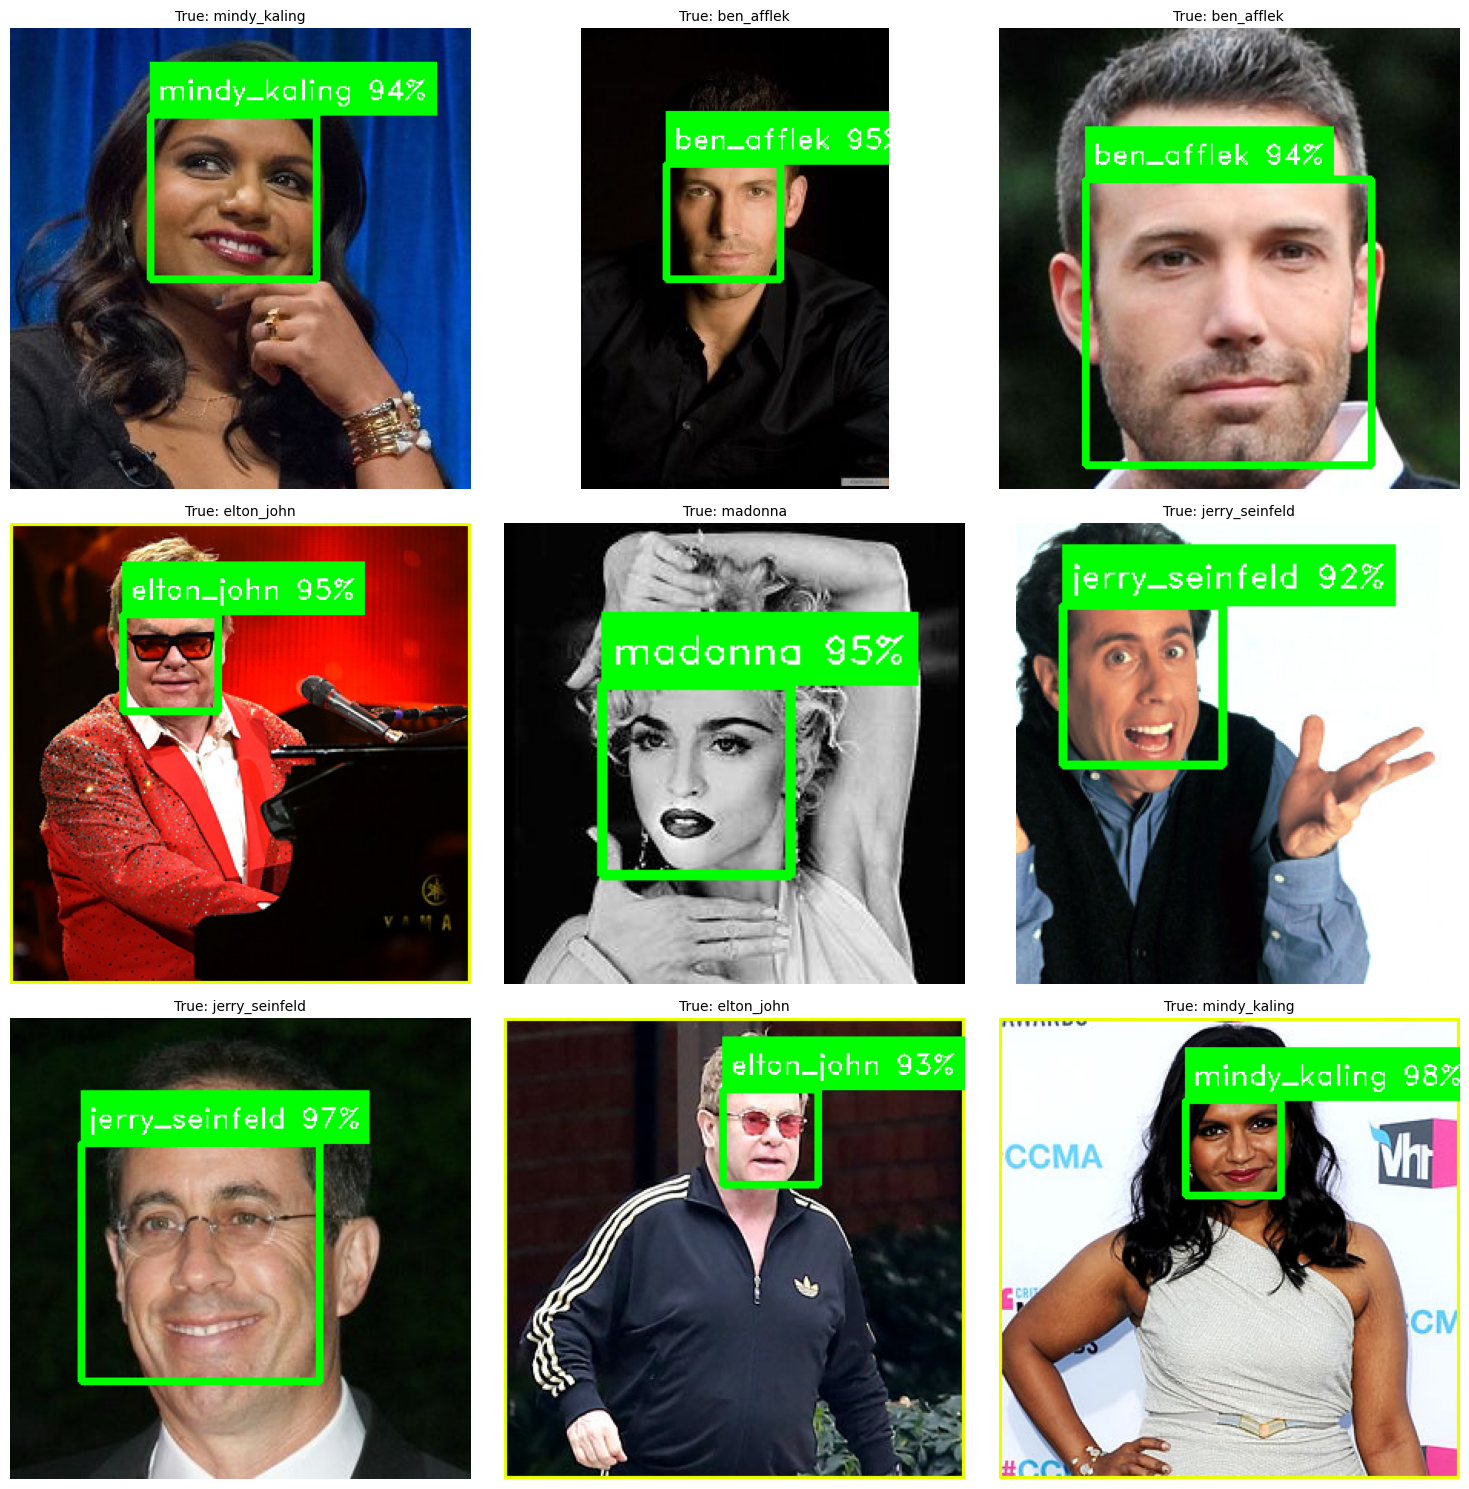

In [17]:
NUM_IMAGES_TO_SHOW = 9  # Кількість фото (краще брати квадратне число: 4, 9, 16)
COLS = 3                # Кількість колонок у сітці
ROWS = 3                # Кількість рядків

# Збираємо список усіх доступних тестових фото
all_test_images = []
for root, dirs, files in os.walk(TEST_DIR):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png')):
            all_test_images.append(os.path.join(root, file))

# Перевірка, чи є достатньо фото
if len(all_test_images) < NUM_IMAGES_TO_SHOW:
    print(f"У папці {TEST_DIR} знайдено лише {len(all_test_images)} фото. Покажемо всі.")
    selected_images = all_test_images
else:
    # Вибираємо 9 випадкових фото
    selected_images = random.sample(all_test_images, NUM_IMAGES_TO_SHOW)

print(f"Обробка {len(selected_images)} фотографій...")

# Налаштування графіку
plt.figure(figsize=(15, 15)) # Розмір загальної картинки

for i, img_path in enumerate(selected_images):
    # Читаємо фото
    img = cv2.imread(img_path)
    if img is None:
        continue
    
    # Конвертуємо в RGB
    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Шукаємо обличчя
    face_locations = face_recognition.face_locations(rgb_img)
    face_encodings = face_recognition.face_encodings(rgb_img, face_locations)

    # Обробляємо кожне знайдене обличчя
    for (top, right, bottom, left), face_encoding in zip(face_locations, face_encodings):
        matches = face_recognition.compare_faces(known_face_encodings, face_encoding)
        name = "Unknown"
        color = (255, 0, 0) # Червоний (у форматі RGB для matplotlib)
        probability = 0.0

        face_distances = face_recognition.face_distance(known_face_encodings, face_encoding)
        if len(face_distances) > 0:
            best_match_index = np.argmin(face_distances)
            
            if matches[best_match_index]:
                name = known_face_names[best_match_index]
                distance = face_distances[best_match_index]
                probability = face_distance_to_conf(distance) * 100
                color = (0, 255, 0) # Зелений
        
        # Малюємо саму рамку навколо обличчя
        cv2.rectangle(rgb_img, (left, top), (right, bottom), color, 3)

        # Готуємо текст
        text = f"{name} {probability:.0f}%"
        font = cv2.FONT_HERSHEY_DUPLEX
        font_scale = 0.6
        font_thickness = 1
        
        # Дізнаємося розмір тексту, щоб намалювати під нього фон
        (text_width, text_height), baseline = cv2.getTextSize(text, font, font_scale, font_thickness)

        # Малюємо прямокутник-фон для тексту (над обличчям)
        # Якщо зверху мало місця, малюємо всередині рамки
        if top - text_height - 10 < 0:
            text_y = top + text_height + 10
            # Фон
            cv2.rectangle(rgb_img, (left, top), (left + text_width + 10, top + text_height + 15), color, cv2.FILLED)
        else:
            text_y = top - 10
            # Фон
            cv2.rectangle(rgb_img, (left, top - text_height - 20), (left + text_width + 10, top), color, cv2.FILLED)

        # Пишемо білий текст на кольоровому фоні
        cv2.putText(rgb_img, text, (left + 5, text_y), font, font_scale, (255, 255, 255), font_thickness)

    # Додаємо картинку в сітку
    plt.subplot(ROWS, COLS, i + 1)
    plt.imshow(rgb_img)
    plt.axis('off') # Прибираємо осі координат
    
    # Спроба вивести справжнє ім'я з назви папки для порівняння
    true_label = os.path.basename(os.path.dirname(img_path))
    plt.title(f"True: {true_label}", fontsize=10)

plt.tight_layout()
plt.show()